In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import anndata as ad
import os
import scanpy as sc
from scipy.stats import linregress

import matplotlib as mpl

from watermark import watermark
print(watermark())
print(watermark(packages="pandas,numpy,matplotlib,scipy,seaborn"))

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

plt.rcParams['svg.fonttype'] = 'none'

Last updated: 2026-07-19T15:57:51.417388-07:00

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.6.0

Compiler    : MSC v.1944 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 63 Stepping 2, GenuineIntel
CPU cores   : 72
Architecture: 64bit

pandas    : 2.2.3
numpy     : 2.1.2
matplotlib: 3.10.7
scipy     : 1.14.1
seaborn   : 0.13.2



### Mean decoded barcodes per mouse cortex cell reported in the text:

In [ ]:
means_by_method = pd.read_csv('mean_cnts_by_method.csv')

In [ ]:
means_by_method.set_index("gene", inplace=True)

In [ ]:
means_by_method.columns

Index(['seqFISH', 'Vizgen MERFISH', 'CosMx', 'Xenium'], dtype='object')

In [ ]:
def bootstrap(matched_genes):
    rep_slopes = []
    rep_r_sq_s = []

    rep_intercepts = []
    
    reps = 10000
    n_matched_genes = len(matched_genes)
    for rep in range(reps):
        matched_genes_subsample = matched_genes.sample(n=int(np.ceil(n_matched_genes*0.7)))
        fit = linregress(matched_genes_subsample[method_i], matched_genes_subsample[method_j])

        rep_slopes.append(fit.slope)
        rep_r_sq_s.append(fit.rvalue)
        rep_intercepts.append(fit.intercept)
        
    rep_params_df = pd.DataFrame({"intercept": rep_intercepts, "r_sq" : rep_r_sq_s, "slope" : rep_slopes})

    rep_params_df.sort_values('slope', inplace=True)
    rep_params_df.reset_index(inplace=True, drop=True)
    return rep_params_df.iloc[[249,9749]]

In [ ]:
means_by_method

,seqFISH,Vizgen MERFISH,CosMx,Xenium
gene,,,,
4930452B06Rik,NaN,0.635114,NaN,NaN
6330403K07Rik,NaN,NaN,1.701662,NaN
A1cf,NaN,NaN,NaN,0.001124
A2m,NaN,0.575704,NaN,0.060121
A830009L08Rik,NaN,0.167741,NaN,NaN
...,...,...,...,...
Zup1,NaN,NaN,NaN,0.047631
Zwint,NaN,NaN,6.674890,NaN
Zyx,4.552558,NaN,NaN,0.146803


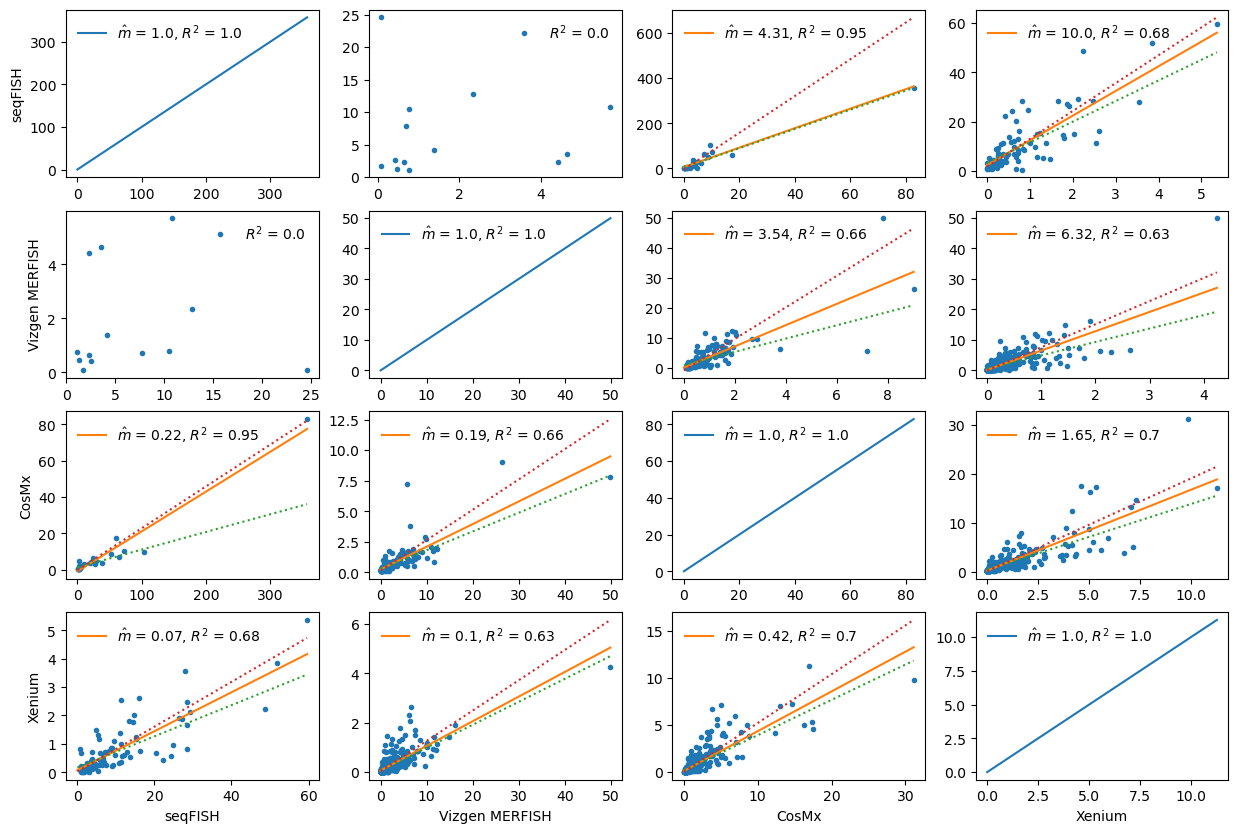

In [ ]:

fig, ax = plt.subplots(4,4, figsize= [15,10])
for i, method_i in enumerate(means_by_method.columns):
    ax[i,0].set_ylabel(method_i)
    ax[3,i].set_xlabel(method_i)
    for j, method_j in enumerate(means_by_method.columns):
        #matched_genes = pd.DataFrame({method_i: means_by_method[method_i], method_j : means_by_method[method_j]}).dropna()
        if method_i == method_j:
            matched_genes = means_by_method.loc[:, method_i].dropna()
            fit = linregress(matched_genes, matched_genes)
            slope_label = r"$\hat m$ = {best}".format(best=np.round(fit.slope,2)) #, low=bounds['el_slope'], up=bounds['eu_slope'])
            r_sq_label = r", $R^2$ = {r_sq}".format(r_sq=np.round(fit.rvalue**2, 2)) #, low=bounds['el_r_sq'], up=bounds['eu_r_sq'])
            label_text = slope_label + r_sq_label

            ax[j,i].plot([0, np.max(matched_genes)], [fit.intercept, fit.intercept + fit.slope *np.max(matched_genes)], label = label_text)
            ax[j,i].legend(frameon=False)

        else:
            matched_genes = means_by_method.loc[:, [method_i, method_j]].dropna()
            fit = linregress(matched_genes[method_i], matched_genes[method_j])

            if fit.rvalue**2 > 0.1:
                boot_res = bootstrap(matched_genes)
                ax[j,i].plot(matched_genes[method_i], matched_genes[method_j], '.')
                slope_label = r"$\hat m$ = {best}".format(best=np.round(fit.slope,2)) #, low=bounds['el_slope'], up=bounds['eu_slope'])
                r_sq_label = r", $R^2$ = {r_sq}".format(r_sq=np.round(fit.rvalue**2, 2)) #, low=bounds['el_r_sq'], up=bounds['eu_r_sq'])
                label_text = slope_label + r_sq_label
                ax[j,i].plot([0, np.max(matched_genes[method_i])], [fit.intercept, fit.intercept + fit.slope *np.max(matched_genes[method_i])], label = label_text)
                ax[j,i].plot([0, np.max(matched_genes[method_i])], [boot_res['intercept'].iloc[0], boot_res['intercept'].iloc[0] + boot_res['slope'].iloc[0] *np.max(matched_genes[method_i])], ':')#, label = r"$m_\text{l}$ = " + str(np.round(boot_res['slope'].iloc[0],2)))
                ax[j,i].plot([0, np.max(matched_genes[method_i])], [boot_res['intercept'].iloc[1], boot_res['intercept'].iloc[1] + boot_res['slope'].iloc[1] *np.max(matched_genes[method_i])], ':')#, label = r"$m_\text{u}$ = " + str(np.round(boot_res['slope'].iloc[1],2)))
                boot_res['intercept'].iloc[0]
            else:
                ax[j,i].plot(matched_genes[method_i], matched_genes[method_j], '.', label=r"$R^2$ = " + str(np.round(fit.rvalue**2, 2)))
            ax[j,i].legend(frameon=False)

fig.supxlabel("Mean counts per gene", fontsize=16)
fig.supylabel("Mean counts per gene", fontsize=16)
plt.savefig("SFig4A_cortex_benchmark.pdf")